<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/03_Brain_Extraction_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unzipping

In [8]:
import shutil
import os

# source (Drive)
source_dir = 'G:\\My Drive\\brain_ct_project\\processed_data_full'

# destination (local)
extract_dir = 'D:\\My Projects\\Temp\\processed_data_full_extracted'

# check existence
if not os.path.exists(source_dir):
    raise FileNotFoundError(f"Source folder not found: {source_dir}")

# remove old version if exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# copy folder
print("Copying folder...")
shutil.copytree(source_dir, extract_dir)

print("Done.")
print("Copied to:", extract_dir)

Copying folder...
Done.
Copied to: D:\My Projects\Temp\processed_data_full_extracted


# Visual sanity check


Processing train | Total: 2281


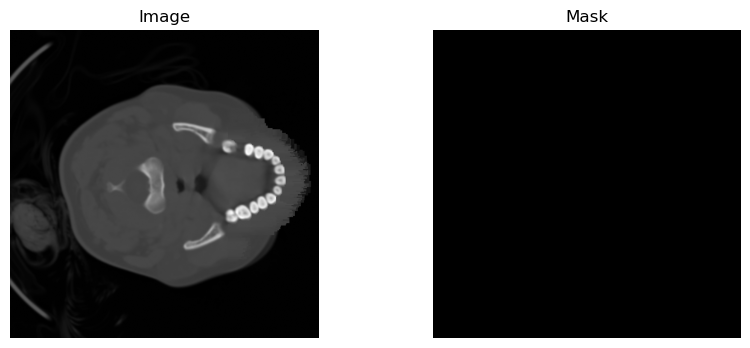

train done.

Processing val | Total: 241


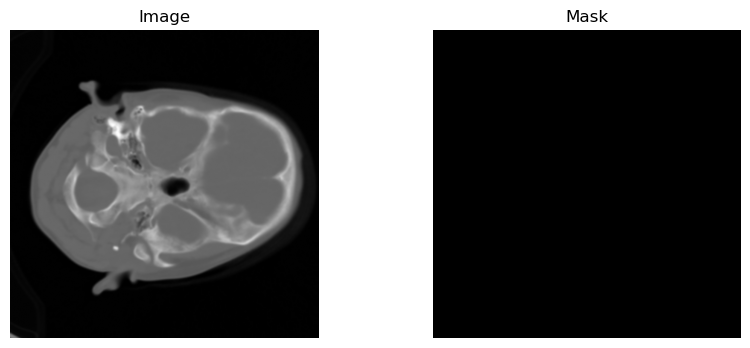

val done.

Processing test | Total: 292


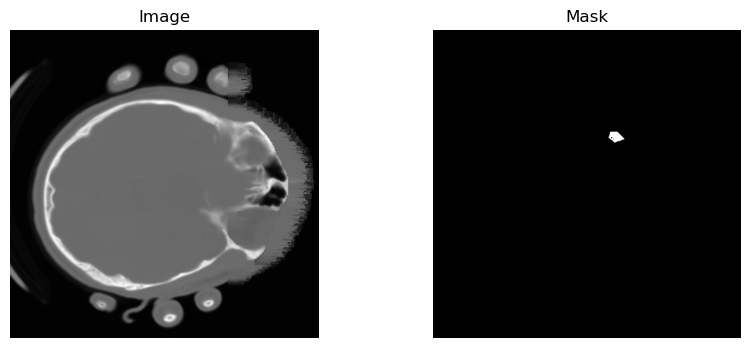

test done.


In [9]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))

    print(f"\nProcessing {split} | Total: {len(files)}")

    sample_file = random.choice(files)

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:
            continue

        if f == sample_file:
            plt.figure(figsize=(10,4))

            plt.subplot(1,2,1)
            plt.imshow(img, cmap='gray')
            plt.title("Image")
            plt.axis('off')

            plt.subplot(1,2,2)
            plt.imshow(mask, cmap='gray')
            plt.title("Mask")
            plt.axis('off')

            plt.show()

    print(f"{split} done.")

# Brain extraction debug


Processing train


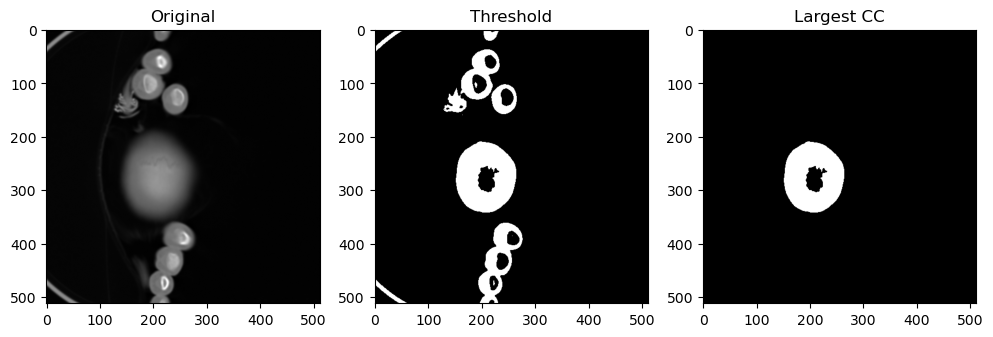

train done.

Processing val


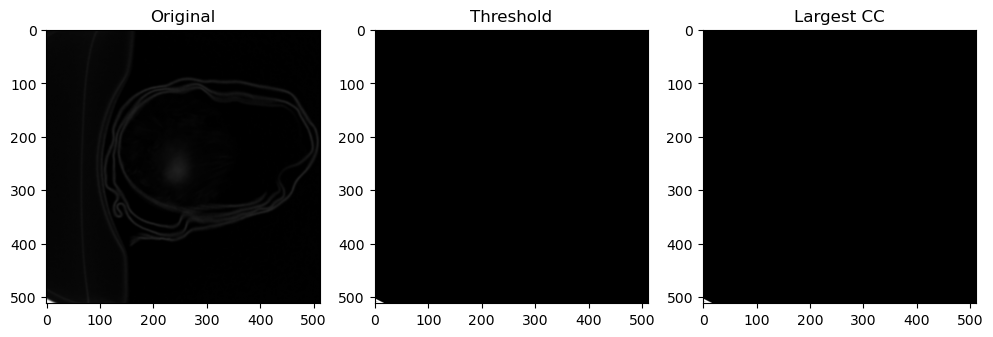

val done.

Processing test


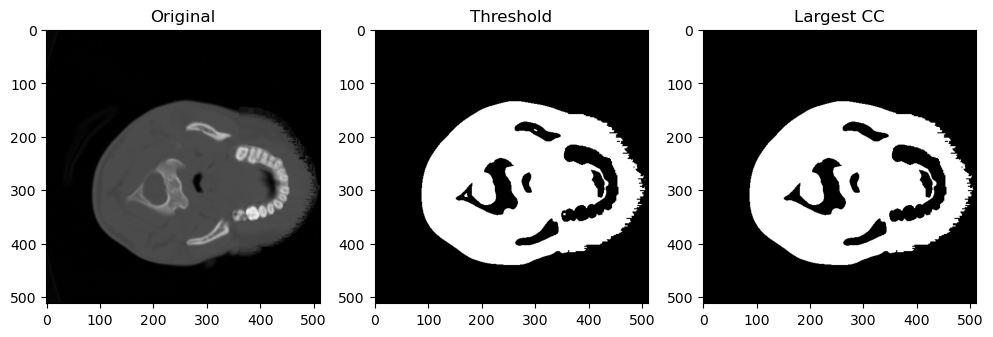

test done.


In [10]:
from scipy.ndimage import label
import matplotlib.pyplot as plt
import random
import numpy as np
import os

splits = ['train', 'val', 'test']

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))
    sample_file = random.choice(files)

    print(f"\nProcessing {split}")

    for f in files:
        img = np.load(os.path.join(img_dir, f))
        mask = np.load(os.path.join(mask_dir, f))

        if img.shape != mask.shape:
            continue

        # FIXED threshold
        brain_mask = (img > -300) & (img < 300)

        labeled, num = label(brain_mask)

        if num > 0:
            sizes = np.bincount(labeled.ravel())[1:]
            brain_mask_clean = (labeled == (np.argmax(sizes) + 1))
        else:
            brain_mask_clean = brain_mask

        if f == sample_file:
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.imshow(img, cmap='gray')
            plt.title("Original")

            plt.subplot(1,3,2)
            plt.imshow(brain_mask, cmap='gray')
            plt.title("Threshold")

            plt.subplot(1,3,3)
            plt.imshow(brain_mask_clean, cmap='gray')
            plt.title("Largest CC")

            plt.show()

    print(f"{split} done.")

# Create save folders

In [11]:
save_root = 'G:\\My Drive\\brain_ct_project\\brain_ct_cropped_resized'

splits = ['train', 'val', 'test']

for split in splits:
    os.makedirs(os.path.join(save_root, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(save_root, split, 'masks'), exist_ok=True)

# FINAL PIPELINE

In [13]:
import os
import numpy as np
import cv2
from scipy.ndimage import label, binary_fill_holes

target_size = (256, 256)

for split in splits:
    img_dir = os.path.join(extract_dir, split, 'images')
    mask_dir = os.path.join(extract_dir, split, 'masks')

    files = sorted(os.listdir(img_dir))

    print(f"\nProcessing {split}")

    for f in files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f)

        if not os.path.exists(mask_path):
            continue

        img = np.load(img_path)
        mask = np.load(mask_path)

        if img.shape != mask.shape:
            continue

        # --- STEP 1: Threshold (FIXED)
        brain_mask = (img > -300) & (img < 300)

        # --- STEP 2: Largest component
        labeled, num = label(brain_mask)

        if num > 0:
            sizes = np.bincount(labeled.ravel())[1:]
            largest_label = np.argmax(sizes) + 1
            brain_mask_clean = (labeled == largest_label)
        else:
            brain_mask_clean = brain_mask

        # --- STEP 3: Fill holes (CRITICAL FIX)
        brain_mask_clean = binary_fill_holes(brain_mask_clean)

        # --- STEP 4: Bounding box + margin
        coords = np.where(brain_mask_clean)

        if coords[0].size == 0:
            cropped_img = img
            cropped_mask = mask
        else:
            y_min, y_max = coords[0].min(), coords[0].max()
            x_min, x_max = coords[1].min(), coords[1].max()

            margin = 10
            y_min = max(0, y_min - margin)
            y_max = min(img.shape[0], y_max + margin)
            x_min = max(0, x_min - margin)
            x_max = min(img.shape[1], x_max + margin)

            cropped_img = img[y_min:y_max+1, x_min:x_max+1]
            cropped_mask = mask[y_min:y_max+1, x_min:x_max+1]

        # --- STEP 5: Resize
        img_resized = cv2.resize(cropped_img, target_size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(cropped_mask, target_size, interpolation=cv2.INTER_NEAREST)

        # --- STEP 6: Clean mask (FIX)
        mask_resized = (mask_resized > 0).astype(np.uint8)

        # --- STEP 7: Safety checks
        if img_resized.shape != (256, 256):
            continue
        if mask_resized.shape != (256, 256):
            continue

        # --- SAVE
        save_img_path = os.path.join(save_root, split, 'images', f)
        save_mask_path = os.path.join(save_root, split, 'masks', f)

        np.save(save_img_path, img_resized.astype(np.float32))
        np.save(save_mask_path, mask_resized.astype(np.uint8))

    print(f"{split} saved.")


Processing train
train saved.

Processing val
val saved.

Processing test
test saved.


# Check sample

In [14]:
import random
import os
import numpy as np

split = 'train'

img_dir = os.path.join(save_root, split, 'images')

files = os.listdir(img_dir)
f = random.choice(files)

sample = np.load(os.path.join(img_dir, f))

print("File:", f)
print("Shape:", sample.shape)
print("Min/Max:", sample.min(), sample.max())

File: slice_02000.npy
Shape: (256, 256)
Min/Max: -1009.75616 1594.4039


# Visualize result

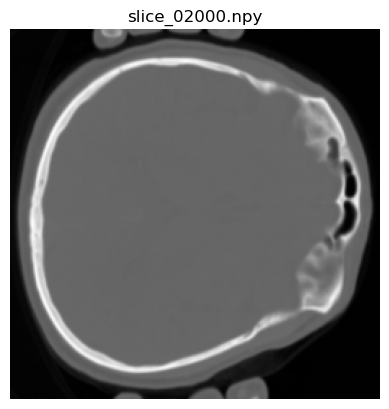

In [15]:
import matplotlib.pyplot as plt

plt.imshow(sample, cmap='gray')
plt.title(f)
plt.axis('off')
plt.show()